# Importación de librerías

In [2]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [3]:
df = dp.lectura(mode=1) # Leyendo 9 primeros individuos
df_val = dp.lectura(mode=2) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [4]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [5]:
del df
del df_val

Se limpia y visualiza el contenido

In [6]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     348
0     348
3     348
4     348
6     348
9     348
10    348
11    348
Name: count, dtype: int64
stimulus
1     72
3     72
0     72
4     72
6     72
9     72
10    72
11    72
Name: count, dtype: int64


# Filtro

In [7]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:25<00:00,  8.54s/it]


In [8]:
del df_block
del df_block_val

# Extracción de características

In [9]:
df_block_features = dp.gen_carac(df_block_filtered)
df_block_features_val = dp.gen_carac(df_block_filtered_val)

Extrayendo Características: 100%|██████████| 576/576 [00:35<00:00, 16.04it/s]


In [10]:
del df_block_filtered
del df_block_filtered_val

In [11]:
df_block_features.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2784.000000,2.784000e+03,2784.000000,2784.000000,2784.000000,2784.00000,2784.000000,2784.000000,2784.000000,2784.000000,...,2784.000000,2.784000e+03,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,0.001894,1.510183e-12,204.489594,76.918463,1489.612428,2449.37967,123.517093,3.727666,0.095150,0.000831,...,0.000229,1.692400e-13,211.318334,73.643678,1779.286279,2901.411997,105.862130,5.720238,0.171245,5.500000
std,0.000962,1.596565e-12,20.336067,17.049214,221.942687,280.66875,52.568928,1.492163,0.028737,0.000415,...,0.000382,5.785921e-12,39.606824,33.820501,504.620277,489.798887,80.142753,6.245455,0.124341,3.905826
min,0.000156,8.549822e-15,155.037607,21.000000,668.000000,1506.00000,17.299662,0.869566,0.040306,0.000132,...,0.000002,6.295396e-19,69.987034,10.000000,478.000000,1345.000000,17.109145,0.434111,0.077290,0.000000
25%,0.001224,5.502253e-13,190.264547,64.000000,1369.750000,2323.00000,86.868450,2.611222,0.075249,0.000561,...,0.000005,7.646595e-18,178.592354,45.000000,1407.000000,2574.000000,40.635264,1.102057,0.098441,2.500000
50%,0.001668,1.006988e-12,201.538750,74.000000,1499.500000,2478.00000,111.961123,3.532881,0.093076,0.000808,...,0.000203,1.567463e-14,197.894084,58.000000,1606.000000,2768.000000,74.124982,4.895803,0.141991,5.000000
75%,0.002282,1.815624e-12,215.034018,87.000000,1640.250000,2639.00000,150.295763,4.640365,0.110286,0.001025,...,0.000357,5.053262e-14,253.754905,113.000000,2331.000000,3357.000000,148.952219,7.929211,0.205834,9.250000
max,0.007494,1.727911e-11,272.156586,128.000000,2160.000000,3200.00000,341.689696,16.125620,0.510944,0.006741,...,0.014477,3.045849e-10,282.842025,123.000000,2698.000000,3920.000000,420.000000,63.151501,2.271510,11.000000


In [12]:
df_block_features_val.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,0.002780,6.305775e-12,202.045353,76.406250,1432.810764,2392.970486,121.140865,5.035307,0.121872,0.002515,...,0.000005,6.181112e-18,254.847526,113.203125,2345.967014,3364.184028,180.926023,1.085224,0.098164,5.500000
std,0.001825,2.384263e-11,23.268697,17.243269,213.459881,263.543764,49.585323,8.639627,0.185769,0.001145,...,0.000001,2.673313e-18,3.174170,2.171449,250.522794,326.519198,70.603591,0.302293,0.007544,3.908519
min,0.000582,1.334558e-13,94.142346,11.000000,757.000000,1609.000000,17.052375,1.466332,0.041007,0.000453,...,0.000002,1.053794e-18,244.808350,105.000000,1370.000000,2332.000000,19.866120,0.490674,0.082850,0.000000
25%,0.001647,1.036574e-12,192.522688,68.000000,1322.750000,2302.750000,86.537183,2.884968,0.073467,0.001743,...,0.000004,4.172443e-18,252.854039,112.000000,2285.750000,3288.000000,147.307767,0.873398,0.093169,2.500000
50%,0.002333,1.893608e-12,201.639683,75.500000,1457.500000,2419.000000,118.884012,3.491472,0.089030,0.002428,...,0.000005,5.611012e-18,254.524378,113.000000,2391.500000,3396.000000,217.548248,1.038978,0.096947,5.000000
75%,0.003494,4.240625e-12,215.190208,87.000000,1572.000000,2584.500000,150.232394,4.351744,0.106699,0.003132,...,0.000005,7.471643e-18,256.468781,114.000000,2542.000000,3603.000000,223.003354,1.253466,0.102004,9.250000
max,0.016546,2.839991e-10,252.673594,112.000000,1940.000000,2907.000000,289.726095,71.539133,1.535564,0.009895,...,0.000007,1.309172e-17,271.736818,121.000000,2668.000000,3830.000000,413.109099,2.568213,0.143700,11.000000


# Normalización

In [13]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize_test_data(scaler, df_block_features_val)

In [14]:
del df_block_features
del df_block_features_val

In [15]:
df_block_normalized.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.000000,2.784000e+03,2.784000e+03,2.784000e+03,...,2.784000e+03,2784.000000,2784.000000,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.000000
mean,3.777311e-16,-9.188053e-17,1.960118e-15,3.675221e-16,2.041789e-17,4.083579e-16,0.000000,-3.675221e-16,2.245968e-16,3.062684e-16,...,8.167158e-17,0.000000,0.000000,1.225074e-16,1.633432e-16,8.167158e-17,-1.225074e-16,4.083579e-17,1.225074e-16,5.500000
std,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180,1.000180e+00,1.000180e+00,1.000180e+00,...,1.000180e+00,1.000180,1.000180,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,3.905826
min,-1.806906e+00,-9.407086e-01,-2.432175e+00,-3.280416e+00,-3.702578e+00,-3.361789e+00,-2.020899,-1.915751e+00,-1.908802e+00,-1.684494e+00,...,-5.946187e-01,-0.029255,-3.568998,-1.882146e+00,-2.579207e+00,-3.178226e+00,-1.107635e+00,-8.465479e-01,-7.557591e-01,0.000000
25%,-6.964087e-01,-6.013721e-01,-6.996241e-01,-7.578521e-01,-5.401573e-01,-4.503614e-01,-0.697279,-7.483395e-01,-6.926445e-01,-6.516318e-01,...,-5.845662e-01,-0.029254,-0.826420,-8.470846e-01,-7.378878e-01,-6.685822e-01,-8.140297e-01,-7.395796e-01,-5.856268e-01,2.500000
50%,-2.354699e-01,-3.152298e-01,-1.451300e-01,-1.712095e-01,4.455812e-02,1.019902e-01,-0.219865,-1.305623e-01,-7.218370e-02,-5.401199e-02,...,-6.757499e-02,-0.026546,-0.338999,-4.626333e-01,-3.434610e-01,-2.724301e-01,-3.960788e-01,-1.320293e-01,-2.353182e-01,5.000000
75%,4.033141e-01,1.913458e-01,5.186017e-01,5.914260e-01,6.788448e-01,6.757232e-01,0.509493,6.117712e-01,5.267961e-01,4.691428e-01,...,3.362428e-01,-0.020520,1.071638,1.163891e+00,1.093521e+00,9.303203e-01,5.377633e-01,3.537564e-01,2.782300e-01,9.250000
max,5.821743e+00,9.878556e+00,3.328035e+00,2.996661e+00,3.021086e+00,2.674880e+00,4.150965,8.310205e+00,1.447134e+01,1.425338e+01,...,3.731608e+01,52.622621,1.806167,1.459623e+00,1.820931e+00,2.079978e+00,3.920433e+00,9.197341e+00,1.689427e+01,11.000000


In [16]:
df_block_normalized_val.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,0.921086,3.004233,-0.120214,-0.030049,-0.255975,-0.201017,-0.045210,0.876496,0.930018,4.062618,...,-0.586252,-2.925450e-02,1.099230,1.169899,1.123186,0.944990,0.936796,-0.742275,-0.587857,5.500000
std,1.897271,14.936387,1.144414,1.011564,0.961952,0.939154,0.943413,5.791042,6.465532,2.761228,...,0.002771,4.621206e-07,0.080156,0.064217,0.496547,0.666759,0.881131,0.048411,0.060679,3.908519
min,-1.364223,-0.862460,-5.427159,-3.867058,-3.301501,-2.994743,-2.025604,-1.515746,-1.884410,-0.910434,...,-0.593946,-2.925539e-02,0.845714,0.927306,-0.811223,-1.162751,-1.073228,-0.837490,-0.711036,0.000000
25%,-0.257246,-0.296695,-0.588563,-0.523195,-0.751962,-0.522523,-0.703582,-0.564851,-0.754676,2.200034,...,-0.588318,-2.925485e-02,1.048889,1.134318,1.003833,0.789421,0.517241,-0.776198,-0.628034,2.500000
50%,0.456409,0.240199,-0.140166,-0.083213,-0.144714,-0.108260,-0.088149,-0.158318,-0.213018,3.850890,...,-0.586574,-2.925460e-02,1.091070,1.163891,1.213435,1.009959,1.393840,-0.749681,-0.597639,5.000000
75%,1.662613,1.710505,0.526283,0.591426,0.371278,0.481509,0.508287,0.418312,0.401963,5.549780,...,-0.584519,-2.925428e-02,1.140171,1.193465,1.511732,1.432657,1.461920,-0.715332,-0.556964,9.250000
max,15.231883,176.967208,2.369812,2.058033,2.029661,1.630757,3.162303,45.453241,50.132258,21.858340,...,-0.579587,-2.925330e-02,1.525730,1.400477,1.761470,1.896196,3.834435,-0.504782,-0.221571,11.000000


# Creación de dataframes de entrenamiento y testeo

In [17]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [18]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [19]:
del df_block_normalized
del df_block_normalized_val

In [20]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1948, 126) (1948,)
(576, 126) (576,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [21]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [22]:
# Visualization libraries

import seaborn as sns

Random forest

In [23]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [24]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [25]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


# Resultados

Random forest

Test data

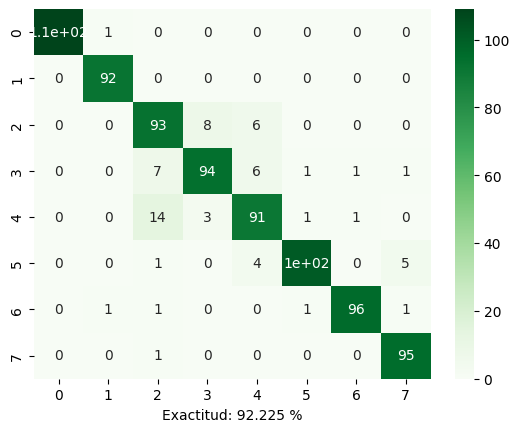

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.98      1.00      0.99        92
           3       0.79      0.87      0.83       107
           4       0.90      0.85      0.87       110
           6       0.85      0.83      0.84       110
           9       0.97      0.91      0.94       111
          10       0.98      0.96      0.97       100
          11       0.93      0.99      0.96        96

    accuracy                           0.92       836
   macro avg       0.93      0.93      0.92       836
weighted avg       0.92      0.92      0.92       836



In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

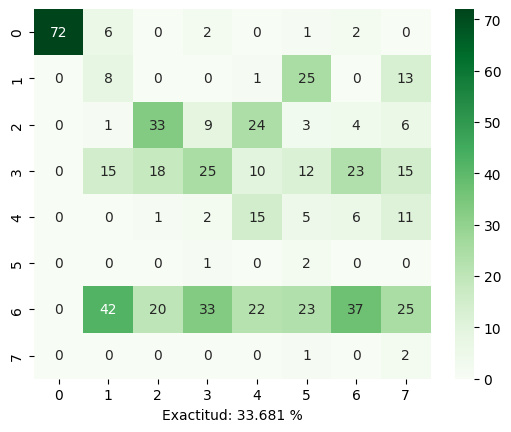

              precision    recall  f1-score   support

           0       1.00      0.87      0.93        83
           1       0.11      0.17      0.13        47
           3       0.46      0.41      0.43        80
           4       0.35      0.21      0.26       118
           6       0.21      0.38      0.27        40
           9       0.03      0.67      0.05         3
          10       0.51      0.18      0.27       202
          11       0.03      0.67      0.05         3

    accuracy                           0.34       576
   macro avg       0.34      0.44      0.30       576
weighted avg       0.48      0.34      0.37       576



In [27]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

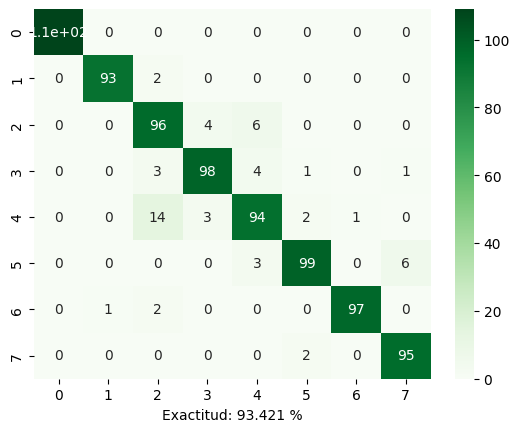

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       0.99      0.98      0.98        95
           3       0.82      0.91      0.86       106
           4       0.93      0.92      0.92       107
           6       0.88      0.82      0.85       114
           9       0.95      0.92      0.93       108
          10       0.99      0.97      0.98       100
          11       0.93      0.98      0.95        97

    accuracy                           0.93       836
   macro avg       0.94      0.94      0.94       836
weighted avg       0.94      0.93      0.93       836



In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

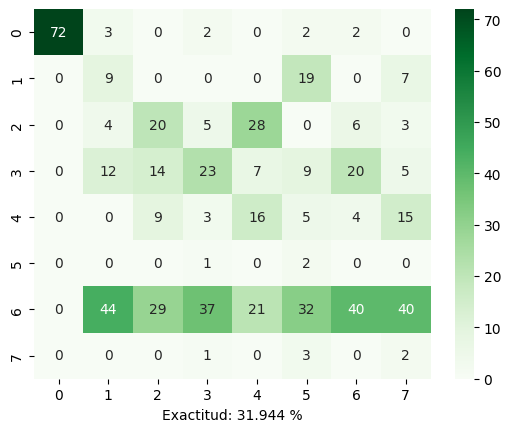

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        81
           1       0.12      0.26      0.17        35
           3       0.28      0.30      0.29        66
           4       0.32      0.26      0.28        90
           6       0.22      0.31      0.26        52
           9       0.03      0.67      0.05         3
          10       0.56      0.16      0.25       243
          11       0.03      0.33      0.05         6

    accuracy                           0.32       576
   macro avg       0.32      0.40      0.29       576
weighted avg       0.48      0.32      0.35       576



In [29]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

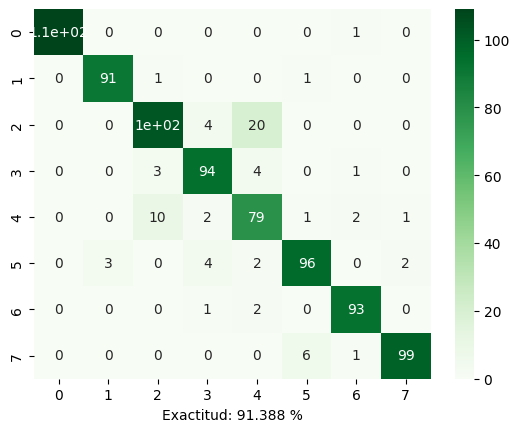

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.97      0.98      0.97        93
           3       0.88      0.81      0.84       127
           4       0.90      0.92      0.91       102
           6       0.74      0.83      0.78        95
           9       0.92      0.90      0.91       107
          10       0.95      0.97      0.96        96
          11       0.97      0.93      0.95       106

    accuracy                           0.91       836
   macro avg       0.92      0.92      0.92       836
weighted avg       0.92      0.91      0.91       836



In [30]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

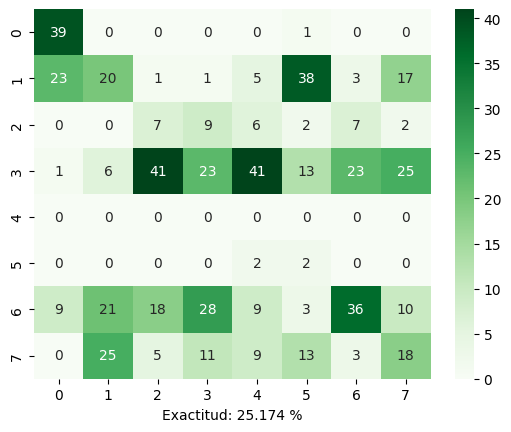

              precision    recall  f1-score   support

           0       0.54      0.97      0.70        40
           1       0.28      0.19      0.22       108
           3       0.10      0.21      0.13        33
           4       0.32      0.13      0.19       173
           6       0.00      0.00      0.00         0
           9       0.03      0.50      0.05         4
          10       0.50      0.27      0.35       134
          11       0.25      0.21      0.23        84

    accuracy                           0.25       576
   macro avg       0.25      0.31      0.23       576
weighted avg       0.34      0.25      0.27       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [31]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [32]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.fit_transform(X_val)

In [33]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(2784, 126)
(2784, 80)
Con PCA
(576, 126)
(576, 80)


Random forest

In [34]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [35]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [36]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# Resultados

Random forest

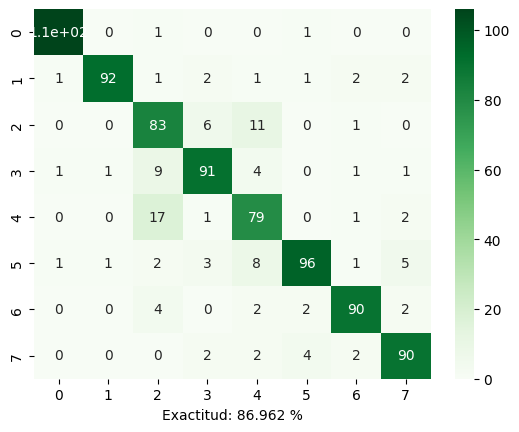

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       108
           1       0.98      0.90      0.94       102
           3       0.71      0.82      0.76       101
           4       0.87      0.84      0.85       108
           6       0.74      0.79      0.76       100
           9       0.92      0.82      0.87       117
          10       0.92      0.90      0.91       100
          11       0.88      0.90      0.89       100

    accuracy                           0.87       836
   macro avg       0.87      0.87      0.87       836
weighted avg       0.88      0.87      0.87       836



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

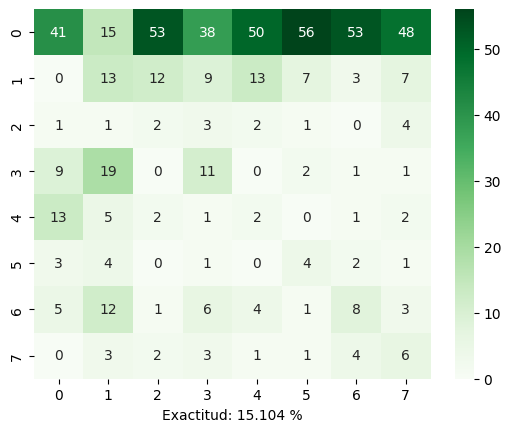

              precision    recall  f1-score   support

           0       0.57      0.12      0.19       354
           1       0.18      0.20      0.19        64
           3       0.03      0.14      0.05        14
           4       0.15      0.26      0.19        43
           6       0.03      0.08      0.04        26
           9       0.06      0.27      0.09        15
          10       0.11      0.20      0.14        40
          11       0.08      0.30      0.13        20

    accuracy                           0.15       576
   macro avg       0.15      0.20      0.13       576
weighted avg       0.40      0.15      0.17       576



In [38]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

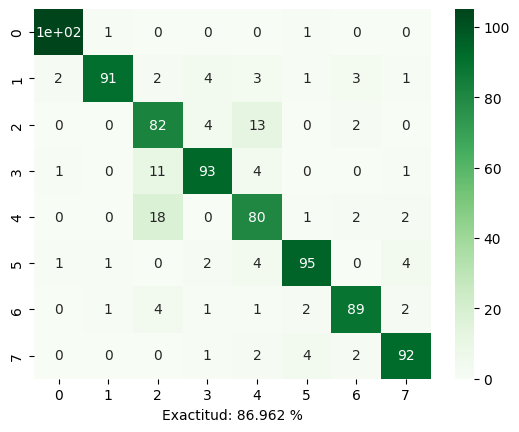

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       107
           1       0.97      0.85      0.91       107
           3       0.70      0.81      0.75       101
           4       0.89      0.85      0.87       110
           6       0.75      0.78      0.76       103
           9       0.91      0.89      0.90       107
          10       0.91      0.89      0.90       100
          11       0.90      0.91      0.91       101

    accuracy                           0.87       836
   macro avg       0.87      0.87      0.87       836
weighted avg       0.88      0.87      0.87       836



In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

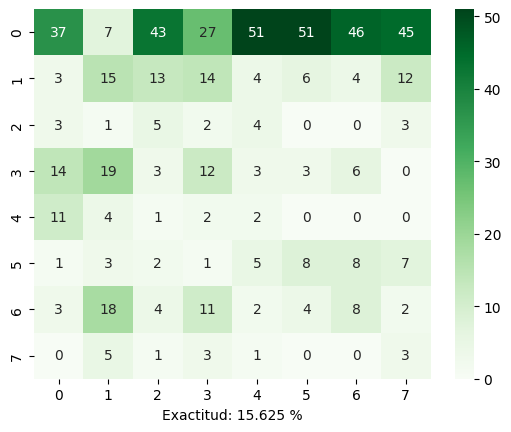

              precision    recall  f1-score   support

           0       0.51      0.12      0.20       307
           1       0.21      0.21      0.21        71
           3       0.07      0.28      0.11        18
           4       0.17      0.20      0.18        60
           6       0.03      0.10      0.04        20
           9       0.11      0.23      0.15        35
          10       0.11      0.15      0.13        52
          11       0.04      0.23      0.07        13

    accuracy                           0.16       576
   macro avg       0.16      0.19      0.14       576
weighted avg       0.34      0.16      0.18       576



In [40]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

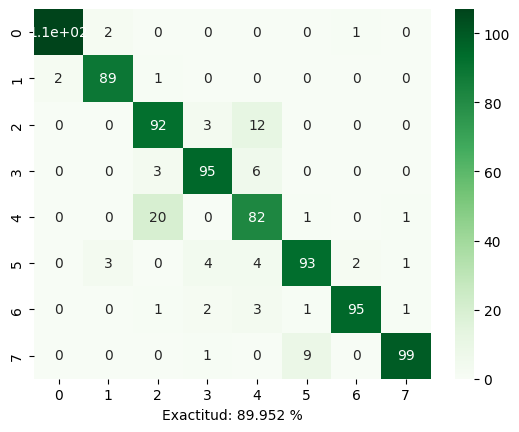

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       110
           1       0.95      0.97      0.96        92
           3       0.79      0.86      0.82       107
           4       0.90      0.91      0.91       104
           6       0.77      0.79      0.78       104
           9       0.89      0.87      0.88       107
          10       0.97      0.92      0.95       103
          11       0.97      0.91      0.94       109

    accuracy                           0.90       836
   macro avg       0.90      0.90      0.90       836
weighted avg       0.90      0.90      0.90       836



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

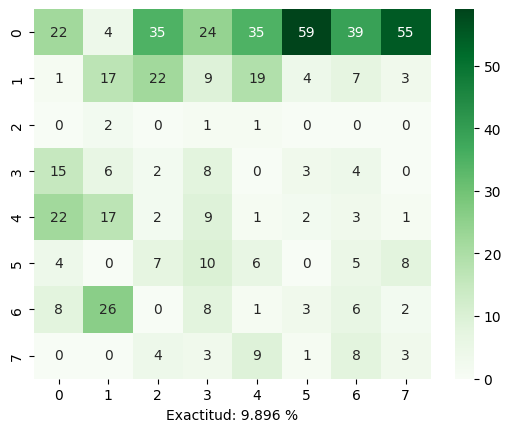

              precision    recall  f1-score   support

           0       0.31      0.08      0.13       273
           1       0.24      0.21      0.22        82
           3       0.00      0.00      0.00         4
           4       0.11      0.21      0.15        38
           6       0.01      0.02      0.02        57
           9       0.00      0.00      0.00        40
          10       0.08      0.11      0.10        54
          11       0.04      0.11      0.06        28

    accuracy                           0.10       576
   macro avg       0.10      0.09      0.08       576
weighted avg       0.20      0.10      0.11       576



In [42]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [43]:
X

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,br_13,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14
0,-0.469499,-0.494848,-0.366628,-0.640524,0.781367,0.779066,-1.207202,0.274170,0.141189,0.319538,...,-0.324418,0.316438,-0.021747,-0.479160,-0.640072,-0.654642,-0.462338,0.054822,0.116178,-0.004707
1,-0.254549,-0.292632,-0.010635,-0.112545,0.276642,0.162571,0.036340,0.145523,-0.257150,0.623122,...,-0.085779,0.622862,-0.014036,-0.686913,-0.492206,-0.860775,-0.956507,-0.281273,-0.143557,-0.219301
2,-0.915468,-0.695764,0.110047,-0.347202,-0.327226,-0.842353,-0.391035,-0.288504,0.038333,-0.454584,...,0.086610,0.129559,-0.022015,-0.888737,-0.669645,-1.146189,-1.391458,-0.547724,0.132165,-0.070160
3,-0.486489,-0.493121,-0.442205,-0.699188,0.844458,0.786194,-0.422542,1.294665,-0.198414,0.432615,...,-0.206803,0.282251,-0.022253,-0.508916,-0.610499,-0.585270,-0.378615,-0.907962,-0.096846,-0.000086
4,-0.721683,-0.598543,-0.493155,-0.581859,0.258616,-0.154586,-0.615498,0.716618,0.003574,0.176710,...,-0.003777,0.117463,-0.024394,-0.621612,-0.462633,-0.914290,-0.917709,-1.013581,-0.037717,0.016480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,-1.085604,-0.775897,-0.395821,-0.816516,-0.687744,0.166134,-0.114319,-0.093012,1.228553,-1.676192,...,0.340167,-0.586230,-0.029255,1.060843,1.193465,1.204515,0.787379,1.462262,-0.766343,-0.587275
2780,-1.054569,-0.767497,-0.795645,-1.696480,-0.381304,0.034283,-1.658459,2.053958,1.713096,-1.486829,...,-0.145626,-0.585001,-0.029254,1.051791,1.134318,1.662368,1.371397,2.383970,-0.644402,-0.609427
2781,-1.258684,-0.843254,0.116048,-0.816516,-0.255123,0.504672,-1.548946,-0.219416,1.001606,-1.660788,...,-0.054563,-0.586367,-0.029255,1.101851,1.163891,1.218390,0.758791,2.383691,-0.615160,-0.646266
2782,-0.969464,-0.750533,-0.181780,-0.757852,-0.732809,-0.535887,-1.226886,0.496863,0.712133,-1.515368,...,-0.240784,-0.587958,-0.029255,0.990326,1.193465,1.499840,1.412237,1.440946,-0.773077,-0.512710
